# MNIST CNN từ đầu với NumPy (Full 60k, vectorized)

Xây dựng CNN hoàn toàn bằng NumPy, không dùng framework deep learning.

**Kiến trúc:** Conv2D → ReLU → MaxPool → Conv2D → ReLU → MaxPool → Flatten → Dense → ReLU → Dense → Softmax

**Tối ưu:** im2col bằng stride tricks, MaxPool vectorized, Adam optimizer, train full 55k mẫu trong vài phút.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, struct, pickle
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 80

DATA_DIR = Path('../data')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)
print('Data dir :', DATA_DIR.resolve())
print('Model dir:', MODEL_DIR.resolve())

Data dir : D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 04\mnist\data
Model dir: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 04\mnist\models


## 1. Load dữ liệu MNIST từ file idx

In [2]:
def load_mnist_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return data

def load_mnist_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

X_train_full = load_mnist_images(DATA_DIR / 'train-images.idx3-ubyte')
y_train_full = load_mnist_labels(DATA_DIR / 'train-labels.idx1-ubyte')
X_test = load_mnist_images(DATA_DIR / 't10k-images.idx3-ubyte')
y_test = load_mnist_labels(DATA_DIR / 't10k-labels.idx1-ubyte')

print('Train:', X_train_full.shape, y_train_full.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


### Split train/val + normalize (full 60k, giữ 28x28)

In [3]:
N_VAL = 5000

idx = np.random.permutation(len(X_train_full))
X_val = X_train_full[idx[:N_VAL]]; y_val = y_train_full[idx[:N_VAL]]
X_train = X_train_full[idx[N_VAL:]]; y_train = y_train_full[idx[N_VAL:]]

def prep(X):
    return (X.astype(np.float32) / 255.0)[:, None, :, :]  # NCHW

X_train = prep(X_train)
X_val   = prep(X_val)
X_test_t= prep(X_test)

print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test_t.shape)

Train: (55000, 1, 28, 28) | Val: (5000, 1, 28, 28) | Test: (10000, 1, 28, 28)


## 2. EDA - Khám phá dữ liệu

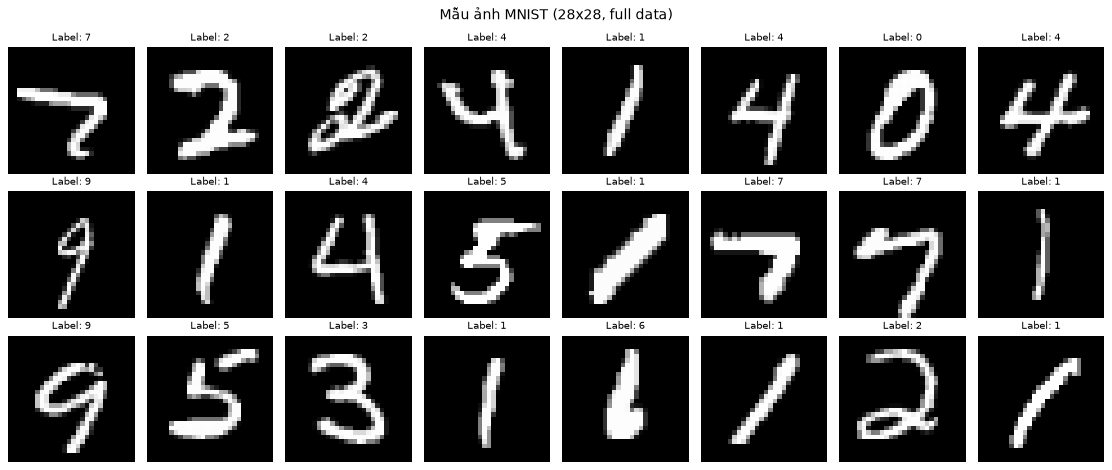

In [4]:
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i, 0], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Mẫu ảnh MNIST (28x28, full data)', fontsize=13)
plt.tight_layout()
plt.show()

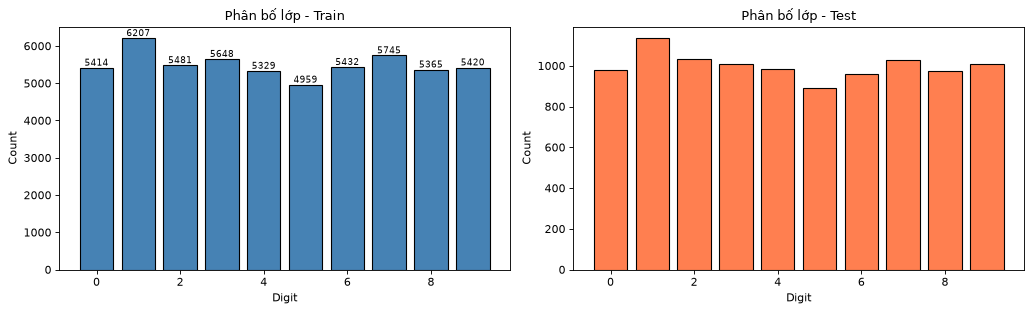

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
unique, counts = np.unique(y_train, return_counts=True)
axes[0].bar(unique, counts, color='steelblue', edgecolor='k')
axes[0].set_title('Phân bố lớp - Train')
axes[0].set_xlabel('Digit'); axes[0].set_ylabel('Count')
for i, c in zip(unique, counts):
    axes[0].text(i, c, str(c), ha='center', va='bottom', fontsize=8)

unique_t, counts_t = np.unique(y_test, return_counts=True)
axes[1].bar(unique_t, counts_t, color='coral', edgecolor='k')
axes[1].set_title('Phân bố lớp - Test')
axes[1].set_xlabel('Digit'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Các layer cơ bản (NumPy, vectorized)

### 3.1. im2col / col2im dùng stride tricks

Layout: `cols` có shape `(C*k*k, N*H_out*W_out)` để nhân ma trận với `W` reshape `(out_c, C*k*k)`.

In [6]:
from numpy.lib.stride_tricks import as_strided

def im2col(X, k, s, p):
    """X: (N, C, H, W) -> cols: (C*k*k, N*Ho*Wo)"""
    N, C, H, W = X.shape
    Ho = (H + 2*p - k)//s + 1
    Wo = (W + 2*p - k)//s + 1
    Xp = np.pad(X, ((0,0),(0,0),(p,p),(p,p))) if p > 0 else X
    Xp = np.ascontiguousarray(Xp)
    shape = (N, C, Ho, Wo, k, k)
    strides = (Xp.strides[0], Xp.strides[1],
               Xp.strides[2]*s, Xp.strides[3]*s,
               Xp.strides[2], Xp.strides[3])
    patches = as_strided(Xp, shape=shape, strides=strides)
    # (N, C, Ho, Wo, k, k) -> (N*Ho*Wo, C*k*k) -> .T -> (C*k*k, N*Ho*Wo)
    cols = patches.transpose(0, 2, 3, 1, 4, 5).reshape(N*Ho*Wo, C*k*k)
    return cols.T, Ho, Wo


def col2im(dcols, X_shape, k, s, p):
    """dcols: (C*k*k, N*Ho*Wo) -> dX: (N, C, H, W)"""
    N, C, H, W = X_shape
    Ho = (H + 2*p - k)//s + 1
    Wo = (W + 2*p - k)//s + 1

    # Reshape rõ ràng 2 bước để tránh nhầm layout
    # dcols: (C*k*k, N*Ho*Wo)
    # Bước 1: tách chiều thứ 0 thành (C, k, k)
    dcols = dcols.reshape(C, k, k, N, Ho, Wo)
    # Bây giờ: dcols[c, i, j, n, ho, wo] = grad tại kênh c, kernel (i,j), batch n, output (ho,wo)

    dXp = np.zeros((N, C, H + 2*p, W + 2*p), dtype=dcols.dtype)
    for i in range(k):
        for j in range(k):
            # dcols[:, i, j] : (C, N, Ho, Wo)  ??? hay (N, Ho, Wo) ???
            # In debug để kiểm tra
            # print('shape:', dcols[:, i, j].shape)

            # CÁCH AN TOÀN: chuyển về (N, C, Ho, Wo) bằng transpose
            grad_ij = dcols[:, i, j]           # hy vọng (C, N, Ho, Wo)
            # Chuyển về (N, C, Ho, Wo)
            grad_ij = grad_ij.transpose(1, 0, 2, 3)  # (N, C, Ho, Wo)

            dXp[:, :, i:i+Ho*s:s, j:j+Wo*s:s] += grad_ij
    return dXp[:, :, p:-p, p:-p] if p > 0 else dXp
print('im2col / col2im OK')

im2col / col2im OK


### 3.2. Conv2D với Adam cache

In [7]:
class Conv2D:
    def __init__(self, in_c, out_c, k=3, s=1, p=1):
        self.W = (np.random.randn(out_c, in_c, k, k).astype(np.float32)
                  * np.sqrt(2.0/(in_c*k*k)))
        self.b = np.zeros(out_c, dtype=np.float32)
        self.k, self.s, self.p = k, s, p
        self.in_c, self.out_c = in_c, out_c
        # Adam cache
        self.mW = np.zeros_like(self.W); self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)

    def forward(self, X):
        self.X_shape = X.shape
        cols, Ho, Wo = im2col(X, self.k, self.s, self.p)   # (C*k*k, N*Ho*Wo)
        self.cols = cols
        self.Ho, self.Wo = Ho, Wo
        N = X.shape[0]
        W_col = self.W.reshape(self.out_c, -1)             # (out_c, C*k*k)
        out = W_col @ cols + self.b[:, None]               # (out_c, N*Ho*Wo)
        return out.reshape(self.out_c, N, Ho, Wo).transpose(1, 0, 2, 3)

    def backward(self, dout):
        N, out_c, Ho, Wo = dout.shape
        W_col = self.W.reshape(self.out_c, -1)
        dout_flat = dout.transpose(1, 0, 2, 3).reshape(out_c, -1)
        self.dW = (dout_flat @ self.cols.T).reshape(self.W.shape)
        self.db = dout_flat.sum(axis=1)
        dcols = W_col.T @ dout_flat
        return col2im(dcols, self.X_shape, self.k, self.s, self.p)

    def step_adam(self, lr, t, b1=0.9, b2=0.999, eps=1e-8):
        self.mW = b1*self.mW + (1-b1)*self.dW
        self.vW = b2*self.vW + (1-b2)*self.dW**2
        self.W -= lr * (self.mW/(1-b1**t)) / (np.sqrt(self.vW/(1-b2**t)) + eps)
        self.mb = b1*self.mb + (1-b1)*self.db
        self.vb = b2*self.vb + (1-b2)*self.db**2
        self.b -= lr * (self.mb/(1-b1**t)) / (np.sqrt(self.vb/(1-b2**t)) + eps)

print('Conv2D OK')

Conv2D OK


### 3.3. ReLU, MaxPool2D, Flatten, Dense, softmax

In [8]:
def relu(x): return np.maximum(0, x)
def relu_grad(x): return (x > 0).astype(np.float32)


class MaxPool2D:
    def __init__(self, k=2, s=2):
        self.k, self.s = k, s

    def forward(self, X):
        N, C, H, W = X.shape
        k, s = self.k, self.s
        Ho = (H - k)//s + 1; Wo = (W - k)//s + 1
        shape = (N, C, Ho, Wo, k, k)
        strides = (X.strides[0], X.strides[1],
                   X.strides[2]*s, X.strides[3]*s,
                   X.strides[2], X.strides[3])
        patches = as_strided(X, shape=shape, strides=strides).reshape(N, C, Ho, Wo, k*k)
        idx = patches.argmax(axis=-1)
        out = np.take_along_axis(patches, idx[..., None], axis=-1)[..., 0]
        self.X_shape = X.shape; self.idx = idx
        self.Ho, self.Wo = Ho, Wo
        return out

    def backward(self, dout):
        N, C, H, W = self.X_shape
        k, s, Ho, Wo = self.k, self.s, self.Ho, self.Wo
        dX = np.zeros((N, C, H, W), dtype=dout.dtype)
        dout_flat = dout.reshape(N, C, Ho, Wo)
        r = self.idx // k; c = self.idx % k
        ii = np.arange(Ho)[None, None, :, None]
        jj = np.arange(Wo)[None, None, None, :]
        rows = ii*s + r; cols = jj*s + c
        n_idx = np.arange(N)[:, None, None, None]
        c_idx = np.arange(C)[None, :, None, None]
        np.add.at(dX, (n_idx, c_idx, rows, cols), dout_flat)
        return dX


class Flatten:
    def forward(self, X):
        self.shape = X.shape
        return X.reshape(X.shape[0], -1)
    def backward(self, d):
        return d.reshape(self.shape)


class Dense:
    def __init__(self, in_f, out_f):
        self.W = np.random.randn(in_f, out_f).astype(np.float32) * np.sqrt(2.0/in_f)
        self.b = np.zeros(out_f, dtype=np.float32)
        self.mW = np.zeros_like(self.W); self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dout):
        self.dW = self.X.T @ dout
        self.db = dout.sum(axis=0)
        return dout @ self.W.T

    def step_adam(self, lr, t, b1=0.9, b2=0.999, eps=1e-8):
        self.mW = b1*self.mW + (1-b1)*self.dW
        self.vW = b2*self.vW + (1-b2)*self.dW**2
        self.W -= lr * (self.mW/(1-b1**t)) / (np.sqrt(self.vW/(1-b2**t)) + eps)
        self.mb = b1*self.mb + (1-b1)*self.db
        self.vb = b2*self.vb + (1-b2)*self.db**2
        self.b -= lr * (self.mb/(1-b1**t)) / (np.sqrt(self.vb/(1-b2**t)) + eps)


def softmax(x):
    x = x - x.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=1, keepdims=True)

print('Layers OK')

Layers OK


## 4. Mô hình CNN (classifier)

In [9]:
class CNN:
    def __init__(self):
        # 28x28 -> conv1 -> 28x28 -> pool -> 14x14 -> conv2 -> 14x14 -> pool -> 7x7
        self.conv1 = Conv2D(1, 8, k=3, s=1, p=1)    # -> 8 x 28 x 28
        self.pool1 = MaxPool2D(2, 2)                 # -> 8 x 14 x 14
        self.conv2 = Conv2D(8, 16, k=3, s=1, p=1)   # -> 16 x 14 x 14
        self.pool2 = MaxPool2D(2, 2)                 # -> 16 x 7 x 7
        self.flat = Flatten()
        self.fc1 = Dense(16*7*7, 128)                # 784 -> 128
        self.fc2 = Dense(128, 10)
        self.t = 0   # Adam step counter

    def forward(self, X):
        x = self.conv1.forward(X); self.a1 = x; x = relu(x)
        x = self.pool1.forward(x)
        x = self.conv2.forward(x); self.a2 = x; x = relu(x)
        x = self.pool2.forward(x)
        x = self.flat.forward(x)
        x = self.fc1.forward(x); self.a3 = x; x = relu(x)
        x = self.fc2.forward(x)
        return softmax(x)

    def backward(self, probs, y):
        N = probs.shape[0]
        d = probs.copy(); d[np.arange(N), y] -= 1; d /= N
        d = self.fc2.backward(d)
        d = d * relu_grad(self.a3)
        d = self.fc1.backward(d)
        d = self.flat.backward(d)
        d = self.pool2.backward(d)
        d = d * relu_grad(self.a2)
        d = self.conv2.backward(d)
        d = self.pool1.backward(d)
        d = d * relu_grad(self.a1)
        d = self.conv1.backward(d)

    def step_adam(self, lr):
        self.t += 1
        for layer in [self.conv1, self.conv2, self.fc1, self.fc2]:
            layer.step_adam(lr, self.t)

    def params(self):
        return [self.conv1.W, self.conv1.b, self.conv2.W, self.conv2.b,
                self.fc1.W, self.fc1.b, self.fc2.W, self.fc2.b]

print('CNN class OK')

CNN class OK


## 5. Training (Adam, batch 128, 5 epochs)

In [10]:
def accuracy(model, X, y, bs=512):
    correct = 0
    for i in range(0, len(X), bs):
        p = model.forward(X[i:i+bs])
        correct += (p.argmax(1) == y[i:i+bs]).sum()
    return correct / len(X)

def cross_entropy(probs, y):
    eps = 1e-9
    return -np.log(probs[np.arange(len(y)), y] + eps).mean()

model = CNN()
EPOCHS = 5
BATCH = 128
LR = 1e-3

n_params = sum(p.size for p in model.params())
print(f'Số tham số: {n_params:,}')
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test_t):,}')
print(f'Epochs: {EPOCHS} | Batch: {BATCH} | LR (Adam): {LR}\n')

history = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}
start = time.time()

for ep in range(EPOCHS):
    ep_start = time.time()
    idx = np.random.permutation(len(X_train))
    Xs, ys = X_train[idx], y_train[idx]
    ep_loss = 0.0; n_batch = 0
    for i in range(0, len(Xs), BATCH):
        xb, yb = Xs[i:i+BATCH], ys[i:i+BATCH]
        p = model.forward(xb)
        ep_loss += cross_entropy(p, yb)
        n_batch += 1
        model.backward(p, yb)
        model.step_adam(LR)
    tr_loss = ep_loss / n_batch
    tr_acc = accuracy(model, X_train, y_train)

    val_probs = []
    for i in range(0, len(X_val), 512):
        val_probs.append(model.forward(X_val[i:i+512]))
    val_probs = np.concatenate(val_probs)
    val_loss = cross_entropy(val_probs, y_val)
    val_acc = (val_probs.argmax(1) == y_val).mean()

    history['loss'].append(tr_loss); history['val_loss'].append(val_loss)
    history['acc'].append(tr_acc);   history['val_acc'].append(val_acc)
    print(f'Epoch {ep+1}/{EPOCHS} | loss {tr_loss:.4f} | acc {tr_acc:.4f} | '
          f'val_loss {val_loss:.4f} | val_acc {val_acc:.4f} | time {time.time()-ep_start:.1f}s')

print(f'\n✅ Total time: {time.time()-start:.1f}s')

Số tham số: 103,018
Train: 55,000 | Val: 5,000 | Test: 10,000
Epochs: 5 | Batch: 128 | LR (Adam): 0.001

Epoch 1/5 | loss 0.2511 | acc 0.9756 | val_loss 0.0881 | val_acc 0.9748 | time 91.7s
Epoch 2/5 | loss 0.0763 | acc 0.9846 | val_loss 0.0640 | val_acc 0.9804 | time 91.8s
Epoch 3/5 | loss 0.0547 | acc 0.9863 | val_loss 0.0568 | val_acc 0.9834 | time 93.1s
Epoch 4/5 | loss 0.0434 | acc 0.9889 | val_loss 0.0478 | val_acc 0.9848 | time 91.1s
Epoch 5/5 | loss 0.0351 | acc 0.9895 | val_loss 0.0619 | val_acc 0.9822 | time 94.2s

✅ Total time: 461.9s


## 6. Learning Curves

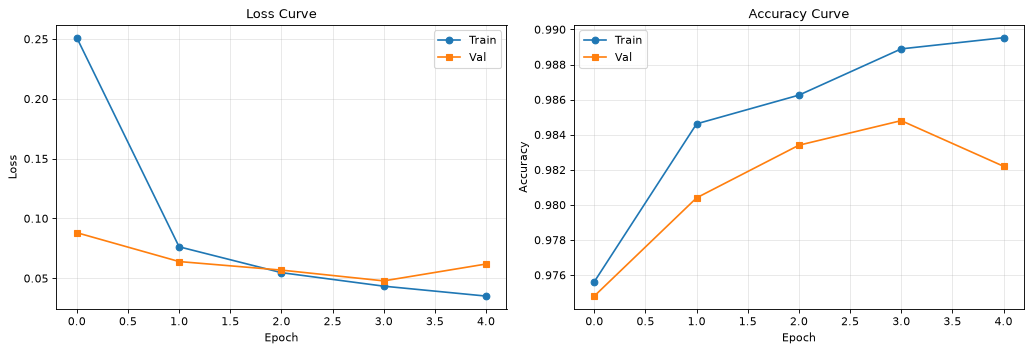

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history['loss'], 'o-', label='Train')
axes[0].plot(history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['acc'], 'o-', label='Train')
axes[1].plot(history['val_acc'], 's-', label='Val')
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Đánh giá trên Test set

In [12]:
test_probs = []
for i in range(0, len(X_test_t), 512):
    test_probs.append(model.forward(X_test_t[i:i+512]))
test_probs = np.concatenate(test_probs)
y_pred = test_probs.argmax(1)
test_acc = (y_pred == y_test).mean()
print(f'🎯 Test Accuracy: {test_acc:.4f}')

🎯 Test Accuracy: 0.9824


## 8. Confusion Matrix

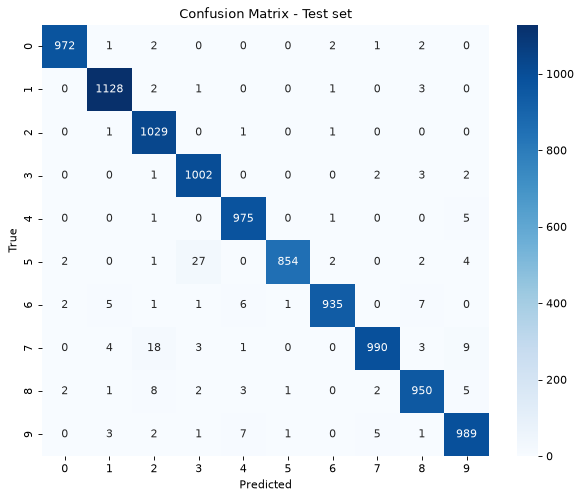

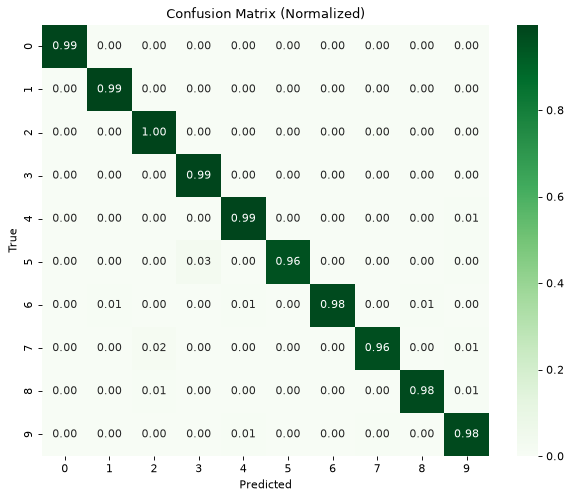

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Test set')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', cbar=True)
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

## 9. Classification Report

In [14]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9939    0.9918    0.9928       980
           1     0.9869    0.9938    0.9903      1135
           2     0.9662    0.9971    0.9814      1032
           3     0.9662    0.9921    0.9790      1010
           4     0.9819    0.9929    0.9873       982
           5     0.9965    0.9574    0.9766       892
           6     0.9926    0.9760    0.9842       958
           7     0.9900    0.9630    0.9763      1028
           8     0.9784    0.9754    0.9769       974
           9     0.9753    0.9802    0.9778      1009

    accuracy                         0.9824     10000
   macro avg     0.9828    0.9820    0.9823     10000
weighted avg     0.9826    0.9824    0.9824     10000



## 10. Xem dự đoán sai

Số mẫu dự đoán sai: 176/10000


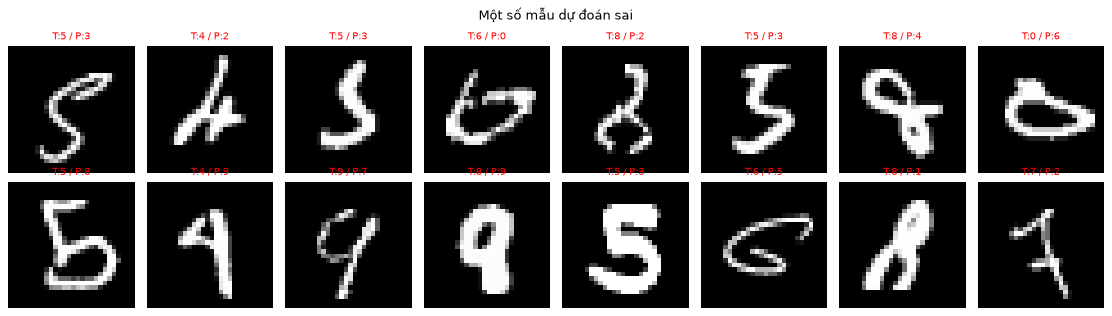

In [15]:
wrong = np.where(y_pred != y_test)[0]
print(f'Số mẫu dự đoán sai: {len(wrong)}/{len(y_test)}')
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    k = wrong[i]
    ax.imshow(X_test_t[k, 0], cmap='gray')
    ax.set_title(f'T:{y_test[k]} / P:{y_pred[k]}', fontsize=9, color='red')
    ax.axis('off')
plt.suptitle('Một số mẫu dự đoán sai', fontsize=12)
plt.tight_layout(); plt.show()

## 11. Lưu best model

In [16]:
save_path = MODEL_DIR / 'mnist_cnn_numpy.pkl'
with open(save_path, 'wb') as f:
    pickle.dump({
        'conv1_W': model.conv1.W, 'conv1_b': model.conv1.b,
        'conv2_W': model.conv2.W, 'conv2_b': model.conv2.b,
        'fc1_W': model.fc1.W, 'fc1_b': model.fc1.b,
        'fc2_W': model.fc2.W, 'fc2_b': model.fc2.b,
        'test_acc': test_acc, 'history': history
    }, f)
print('✅ Saved:', save_path.resolve())
print(f'File size: {save_path.stat().st_size/1024:.1f} KB')

✅ Saved: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 04\mnist\models\mnist_cnn_numpy.pkl
File size: 805.2 KB
